In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('students.csv')
df.shape

(250, 9)

In [6]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   id       250 non-null    int64
 1   Name     250 non-null    str  
 2   Gender   250 non-null    str  
 3   Age      250 non-null    int64
 4   Section  250 non-null    str  
 5   Science  250 non-null    int64
 6   English  250 non-null    int64
 7   History  250 non-null    int64
 8   Maths    250 non-null    int64
dtypes: int64(6), str(3)
memory usage: 17.7 KB


In [7]:
df.describe()

,id,Age,Science,English,History,Maths
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,125.500000,14.020000,51.440000,47.980000,52.272000,53.016000
std,72.312977,0.823598,29.314497,29.949013,26.868526,27.386416
min,1.000000,13.000000,1.000000,1.000000,1.000000,1.000000
25%,63.250000,13.000000,25.250000,20.250000,31.000000,30.000000
50%,125.500000,14.000000,53.000000,47.500000,53.000000,52.500000
75%,187.750000,15.000000,78.000000,74.000000,76.000000,76.000000
max,250.000000,15.000000,100.000000,100.000000,100.000000,100.000000


In [8]:
df["Average"] = df[["Science","English","History","Maths"]].mean(axis=1)
df.head()

,id,Name,Gender,Age,Section,Science,English,History,Maths,Average
0,1,Bronnie,Female,13,C,21,81,62,49,53.25
1,2,Lemmie,Male,15,B,29,41,17,40,31.75
2,3,Danya,Female,14,C,12,87,16,96,52.75
3,4,Denna,Female,14,B,15,53,82,33,45.75
4,5,Jocelin,Male,14,A,43,6,3,21,18.25


In [9]:
top_student = df.loc[df["Average"].idxmax()]
print(top_student[["Name","Average"]])

Name        Dunn
Average    90.25
Name: 10, dtype: object


In [10]:
low_student = df.loc[df["Average"].idxmin()]
print(low_student[["Name","Average"]])

Name       Ginnifer
Average       14.25
Name: 228, dtype: object


In [11]:
df["Status"] = df["Average"].apply(lambda x: "Pass" if x >= 50 else "Fail")
df.head()

,id,Name,Gender,Age,Section,Science,English,History,Maths,Average,Status
0,1,Bronnie,Female,13,C,21,81,62,49,53.25,Pass
1,2,Lemmie,Male,15,B,29,41,17,40,31.75,Fail
2,3,Danya,Female,14,C,12,87,16,96,52.75,Pass
3,4,Denna,Female,14,B,15,53,82,33,45.75,Fail
4,5,Jocelin,Male,14,A,43,6,3,21,18.25,Fail


In [12]:
pass_count = df[df["Status"]=="Pass"].shape[0]
total = df.shape[0]

pass_percentage = (pass_count/total)*100
print("Pass Percentage:", round(pass_percentage,2), "%")

Pass Percentage: 52.0 %


In [13]:
subject_avg = df[["Science","English","History","Maths"]].mean()
subject_avg

Science    51.440
English    47.980
History    52.272
Maths      53.016
dtype: float64

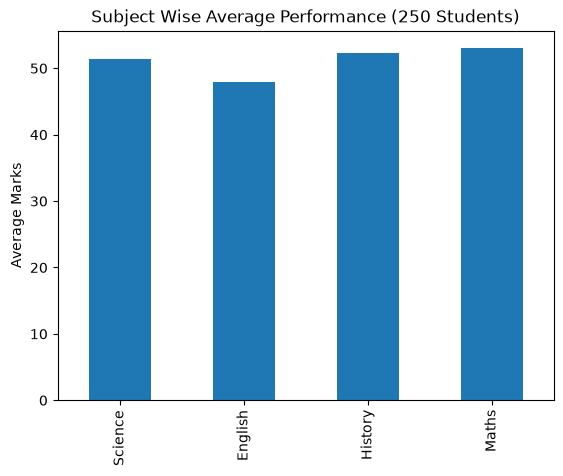

In [14]:
subject_avg.plot(kind="bar")
plt.title("Subject Wise Average Performance (250 Students)")
plt.ylabel("Average Marks")
plt.show()

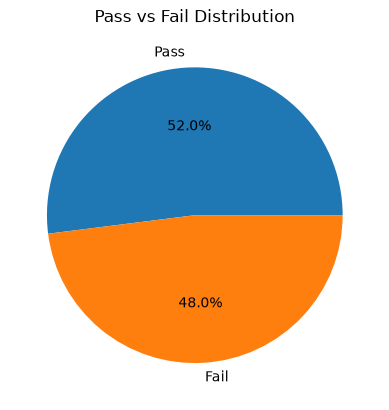

In [15]:
df["Status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Pass vs Fail Distribution")
plt.show()

In [16]:
df.sort_values("Average", ascending=False).head(10)

,id,Name,Gender,Age,Section,Science,English,History,Maths,Average,Status
10,11,Dunn,Male,15,C,100,93,87,81,90.25,Pass
120,121,Patrizia,Male,13,A,79,88,96,93,89.00,Pass
68,69,Nil,Female,15,A,84,97,70,96,86.75,Pass
91,92,Daffi,Female,15,A,79,82,99,81,85.25,Pass
200,201,Ruddie,Female,15,B,84,97,88,64,83.25,Pass
150,151,Herold,Male,13,A,92,97,62,69,80.00,Pass
178,179,Val,Male,13,B,95,73,91,61,80.00,Pass
39,40,Luelle,Male,13,B,100,52,89,76,79.25,Pass
222,223,Leda,Female,15,B,92,76,72,71,77.75,Pass
5,6,Malissa,Female,14,C,98,51,85,76,77.50,Pass


In [17]:
df.sort_values("Average").head(10)

,id,Name,Gender,Age,Section,Science,English,History,Maths,Average,Status
228,229,Ginnifer,Female,14,C,4,15,6,32,14.25,Fail
19,20,Ashlan,Male,13,B,41,6,17,3,16.75,Fail
225,226,Blake,Female,15,B,16,4,49,1,17.50,Fail
4,5,Jocelin,Male,14,A,43,6,3,21,18.25,Fail
137,138,Berget,Male,13,C,10,29,21,13,18.25,Fail
226,227,Josepha,Female,14,C,22,26,1,28,19.25,Fail
245,246,Nickie,Male,13,C,28,15,25,10,19.50,Fail
209,210,Alasteir,Male,13,A,7,29,30,23,22.25,Fail
244,245,Jesselyn,Female,15,C,11,53,15,13,23.00,Fail
239,240,Raimund,Male,15,C,2,4,48,46,25.00,Fail


In [18]:
df.groupby("Gender")["Average"].mean()

Gender
Female    50.654661
Male      51.643939
Name: Average, dtype: float64

In [19]:
df.groupby("Section")["Average"].mean()

Section
A    52.063291
B    52.490506
C    49.288043
Name: Average, dtype: float64

In [20]:
print("===== STUDENT RESULT ANALYSIS REPORT =====")

print("\nTotal Students:", len(df))
print("Top Student:", top_student["Name"], top_student["Average"])
print("Lowest Student:", low_student["Name"], low_student["Average"])
print("Pass Percentage:", round(pass_percentage,2), "%")

print("\nSubject Averages:")
print(subject_avg)

print("\nGender Wise Performance:")
print(df.groupby("Gender")["Average"].mean())

print("\nSection Wise Performance:")
print(df.groupby("Section")["Average"].mean())

===== STUDENT RESULT ANALYSIS REPORT =====

Total Students: 250
Top Student: Dunn 90.25
Lowest Student: Ginnifer 14.25
Pass Percentage: 52.0 %

Subject Averages:
Science    51.440
English    47.980
History    52.272
Maths      53.016
dtype: float64

Gender Wise Performance:
Gender
Female    50.654661
Male      51.643939
Name: Average, dtype: float64

Section Wise Performance:
Section
A    52.063291
B    52.490506
C    49.288043
Name: Average, dtype: float64
